# FEATURE EXTRACTION

In [104]:
# import libraries
import os
import glob
import pandas as pd
import numpy as np
import math
import pyentrp

import pyentrp

from pyentrp import entropy as ent

import scipy
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import math

import xml.etree.ElementTree as ET
import re

# get relevent folders
curfolder = os.getcwd()
print(curfolder)

flesh_folder = os.path.dirname(curfolder)
motion_processing = flesh_folder + '/Motion_Processing_Folder'

mtfolder = motion_processing + '/TS_movement/'
print(mtfolder)

mtfiles = glob.glob(mtfolder + '*.csv')

demographics = curfolder + "/demographicsProcessed.csv"
demographics_nijmegen = curfolder + '/demographicsProcessedNijmegen.csv'

which_arm = curfolder + '/which_arm.csv'
which_arm = pd.read_csv(which_arm)



/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Feature_Extraction_Folder
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/


In [105]:
# returns the total movement of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def gesturespace2D(sample, joint, side, movement_type): 
    #get the subdf for where there is only movement for that tier. 
    fileID = sample["fileID"][0]
    total_movement = int(0)
    movement_sample = sample[sample[movement_type] == 'movement']
    # if the movement type is arms, then check whether the left or right arm has movement and output accordingly. 
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
        # if that specific arm does have movement, return the movement
    # if it is no arms, return the movement
    if movement_sample.empty:
        return 0
    else:
        X_std = np.std(movement_sample["X_" + side + joint])
        Y_std = np.std(movement_sample["Y_" + side + joint])
        total_movement = X_std + Y_std # FLAG: hm, should this really be a sumation or rather squared suM??
        return total_movement


# returns the total entropy of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def entropyts2D(sample, joint, side, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
        # if that specific arm does have movement, return the movement
    if movement_sample.empty:
        return 0
    else:
        speed_ts = (movement_sample[side + joint + "_speed2D"]).values
        sample_entropy = ent.sample_entropy(speed_ts, 1)
        return sample_entropy
    
# returns the total entropy of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate arm movement using the combined timeseries
def entropyts2Daggregated(sample, joint, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
        # if that specific arm does have movement, return the movement
    if movement_sample.empty:
        return 0
    else:
        speed_ts = (movement_sample[joint + "_speed2D"]).values
        sample_entropy = ent.sample_entropy(speed_ts, 1)
        return sample_entropy


# returns the total temporal variability of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate each side's arm movement seprately
def temporal_variability_function2D(sample, joint, side, movement_type):
    fileID = sample["fileID"][0]
    #get the subdf for where there is only movement for that tier. 
    movement_sample = sample[sample[movement_type] == "movement"]
    # calculate each arm separately if there is arm movement
    if movement_type == 'arms':
        if side == "LEFT_": 
            arm = 'l'
        if side == "RIGHT_":
            arm = 'r'
        # if that specific arm has no movement, return zero
        if not which_arm.loc[which_arm['fileID'] == fileID, 'arms'].isin([arm, 'b']).any():
            return 0
    if movement_sample.empty:
        return 0
    else:
        # find the average speed of the speed time series
        speed_ts = (movement_sample[side + joint + "_speed2D"]).to_numpy()
        avg_height = np.mean(speed_ts)
        # calculate the peaks in the speed timeseries with the average speed as the min peak height.
        peaks, _ = scipy.signal.find_peaks(speed_ts, avg_height)
        # determine if there are more than two peaks
        if len(peaks) > 2:
            diff_in_peaks = np.empty(len(peaks)-1)
            # calulcate all the amounts of time between peaks
            for i in range(len(peaks)-1): 
                current_peak = sample.loc[peaks[i], "time" ]
                next_peak = sample.loc[peaks[i+1], "time" ]
                time_between_peaks = next_peak - current_peak
                diff_in_peaks[i] = time_between_peaks
            # find the standard deviation in peak distance
            temporal_variability= np.std(diff_in_peaks)
            return temporal_variability
        else:
            return 0
        

# returns the total temporal variability of a key point given inputed key point and motion processed file
# This function is specifically relevent if you wish to calculate arm movement using the combined timeseries
def temporal_variability_function2Daggregated(sample, joint, movement_type):
    fileID = sample["fileID"][0]
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    else:
        # find the average speed of the speed time series
        speed_ts = (movement_sample[joint + "_speed2D"]).to_numpy()
        avg_height = np.mean(speed_ts)
        # calculate the peaks in the speed timeseries with the average speed as the min peak height.
        peaks, _ = scipy.signal.find_peaks(speed_ts, avg_height)
        # determine if there are more than two peaks
        if len(peaks) > 2:
            diff_in_peaks = np.empty(len(peaks)-1)
            # calulcate all the amounts of time between peaks
            for i in range(len(peaks)-1): 
                current_peak = sample.loc[peaks[i], "time" ]
                next_peak = sample.loc[peaks[i+1], "time" ]
                time_between_peaks = next_peak - current_peak
                diff_in_peaks[i] = time_between_peaks
            # find the standard deviation in peak distance
            temporal_variability= np.std(diff_in_peaks)
            return temporal_variability
        else:
            return 0
    
## feature for the bounding box of movement
def get_bbmv(sample, keypoint, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    # get spans in each dimension
    x_span = sample['X_' + keypoint].max() - sample['X_' + keypoint].min()
    y_span = sample['Y_' + keypoint].max() - sample['Y_' + keypoint].min()
    #z_span = df['Z_' + keypoint].max() - df['Z_' + keypoint].min()

    # calculate bbmv
    bbmv = x_span * y_span #* z_span
    print(bbmv)
    return bbmv

# feature for intermittency
def get_intermittency(df, keypoint, movement_type):
    movement_sample = df[df[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    jerk_values = df[keypoint + "_TOTAL_jerk2D"]
    speed_values = df[keypoint + "_TOTAL_speed2D"]
    """Calculate the dimensionless smoothness measure using precomputed smoothed jerk and speed."""
    smoothed_jerk = jerk_values
    speed = speed_values
    
    if not np.all(speed == 0):
        integrated_squared_jerk = np.sum(smoothed_jerk ** 2)
        max_squared_speed = np.max(speed ** 2)
        D3 = len(speed) ** 3
        jerk_dimensionless = integrated_squared_jerk * (D3 / max_squared_speed)
        smoothness = jerk_dimensionless
    else:
        smoothness = np.nan

    return smoothness

#other features to add: 
# we can calculate total time for arms, upper body, lower body, head (for all of the movement types.)
def time(sample, movement_type): 
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    time_start = movement_sample.iloc[0] ['time']
    time_end = movement_sample.iloc[-1]['time']
    total_time = time_end-time_start
    return total_time

#calculates the total time of the whole gesture
def overall_time(sample):
    movement_types = ['arms', 'lower_body', 'upper_body', 'head_mov']
    earliest_time = np.inf
    latest_time = 0
    for movement_type in movement_types:
        movement_sample = sample[sample[movement_type] == "movement"]
        if movement_sample.empty:
            continue
        time_start = movement_sample.iloc[0] ['time']
        time_end = movement_sample.iloc[-1]['time']
        if time_start < earliest_time:
            earliest_time = time_start
        if time_end > latest_time:
            latest_time = time_end
    # calculates the time from the earliest start to the latest end
    overall_time = time_end - time_start
    return overall_time
        
# function to create columns for the mean speed and acceleration of some keypoints: 
# mean speed
# mean acceleration
# sd speed
# sd acceleration

#keypoints: left wrist, right wrist, knee, 
def mean_keypoint(sample, keypoint, side, measure, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    avg_speed = movement_sample[side + keypoint + '_' + measure + '2D'].mean()
    return avg_speed

def sd_keypoint(sample, keypoint, side, measure, movement_type):
    movement_sample = sample[sample[movement_type] == "movement"]
    if movement_sample.empty:
        return 0
    std_speed = movement_sample[side + keypoint + '_' + measure + '2D'].std()
    return std_speed

In [106]:

featuredf = pd.DataFrame()

# gets the survey information
demographics_read = pd.read_csv(demographics) 

demographics_read_nijmegen = pd.read_csv(demographics_nijmegen) 

# adds survey columns to the features csv file
columns_to_add = demographics_read.columns
for col in columns_to_add:
    #if col != 'participantID':
    featuredf[col] = pd.NA
        #print(col)



## THE CODE BLOCK BELOW IS JUST USED TO TEST MY FUNCTIONS ON ONE FILE

In [95]:
# creates the dataframe of features
featuredf = pd.DataFrame()

# gets the survey information
demographics_read = pd.read_csv(demographics) 

# adds survey columns to the features csv file
columns_to_add = demographics_read.columns
for col in columns_to_add:
    featuredf[col] = pd.NA
file = "/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/leise_g_ch2_g18_compr.eaf.csv"

count = 0
sample = sample = pd.read_csv(file)
movement_sample = sample[sample['arms'] == "movement"]
featuredf.loc[count, "fileID"] = (sample["fileID"])[0]


# get the chainID and the participantID and generation number
featuredf.loc[count, "chainID"] = sample["participantID"][0]
chainID = featuredf["chainID"][count]
split_string = chainID.split('ch')[1]
split_string = split_string.split('g')
chain_num = split_string[0]
gen_num = split_string[1]
featuredf.loc[count, "generation_number"] = int(gen_num)
featuredf.loc[count, "chain_number"] = int(chain_num)
participantID = (int(chain_num) - 1) * 20 + int(gen_num)
gesture = featuredf.loc[count, 'fileID'].split("_")[0]
gesture_chain = (re.split(r"_g\d+", featuredf.loc[count, 'fileID'])[0])
featuredf.loc[count, "participantID"] = participantID
featuredf.loc[count, "gesture"] = gesture
featuredf.loc[count, "gesture_chain"] = gesture_chain

# get the demographic information from the survey and puts it in correct row in featuredf 
matching_rows = demographics_read[demographics_read["participantID"] == int(participantID)]
if len(matching_rows) > 0:
    demographic_row = matching_rows.iloc[0]
    matching_row = demographics_read[demographics_read["participantID"] == int(participantID)]
    featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
else:
    print("no matching demographics row" + "for" + str(participantID))

print(get_bbmv(sample, "LEFT_WRIST", 'arms'))

print(overall_time(sample))
print(time(sample, 'upper_body'))

print(sd_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms"))
sample




movement_sample

0.10398575296187441
0.10398575296187441
4316.666666666663
4316.666666666663
9.24435050649568e-05


,time,X_NOSE,Y_NOSE,Z_NOSE,X_LEFT_EYE_INNER,Y_LEFT_EYE_INNER,Z_LEFT_EYE_INNER,X_LEFT_EYE,Y_LEFT_EYE,Z_LEFT_EYE,...,RIGHT_SHOULDER_jerk2D,LEFT_INDEX_jerk2D,LEFT_HIP_jerk2D,RIGHT_EAR_jerk2D,RIGHT_PINKY_jerk2D,ARM_TOTAL_jerk2D,arms,upper_body,head_mov,lower_body
24,400.000000,0.025197,0.365200,-0.383991,0.044445,0.378753,-0.374138,0.046302,0.378437,-0.361743,...,-1.322087e-06,-0.000007,-1.594567e-07,-4.791852e-07,-1.818395e-06,0.000007,movement,movement,movement,no movement
25,416.666667,0.026472,0.366181,-0.380457,0.045481,0.379731,-0.370503,0.047347,0.379440,-0.358173,...,-1.332814e-06,-0.000009,-1.892833e-07,-2.295547e-07,-1.325916e-06,0.000007,movement,movement,movement,no movement
26,433.333333,0.027714,0.367160,-0.376618,0.046491,0.380704,-0.366533,0.048366,0.380436,-0.354268,...,-1.050294e-06,-0.000010,-1.769919e-07,-1.520344e-08,-7.820150e-07,0.000007,movement,movement,movement,no movement
27,450.000000,0.028955,0.368011,-0.372716,0.047496,0.381533,-0.362506,0.049380,0.381286,-0.350305,...,-5.403513e-07,-0.000009,-1.261764e-07,1.435856e-07,-3.416236e-07,0.000007,movement,movement,movement,no movement
28,466.666667,0.030280,0.368755,-0.368802,0.048525,0.382249,-0.358472,0.050417,0.382024,-0.346332,...,6.830743e-08,-0.000007,-5.618578e-08,2.268252e-07,-1.175615e-07,0.000006,movement,movement,movement,no movement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,4650.000000,-0.051862,0.378061,-0.352728,-0.027197,0.392722,-0.348855,-0.024845,0.392292,-0.337056,...,-1.002443e-07,-0.000014,1.405156e-07,-5.305228e-08,-3.943131e-06,0.000010,movement,movement,movement,no movement
280,4666.666667,-0.051831,0.378115,-0.357810,-0.026898,0.392719,-0.354310,-0.024545,0.392258,-0.342423,...,-4.739378e-08,-0.000015,6.500555e-08,-3.478707e-07,-4.049324e-06,0.000011,movement,movement,movement,no movement
281,4683.333333,-0.051673,0.378029,-0.362537,-0.026477,0.392587,-0.359384,-0.024124,0.392099,-0.347390,...,-4.190510e-08,-0.000014,-3.280536e-10,-5.827564e-07,-3.656040e-06,0.000010,movement,movement,movement,no movement
282,4700.000000,-0.051443,0.377841,-0.367016,-0.026002,0.392352,-0.364168,-0.023656,0.391836,-0.352064,...,-1.105057e-07,-0.000011,-5.296014e-08,-7.366493e-07,-2.794701e-06,0.000008,movement,movement,movement,no movement


# Main For Loop For Feature Extraction

In [107]:
count = 0
nijmegen_gestures  = ['koud', 'langzaam', 'nijmegen_nijmegen_rennen', 'onweer', 'stil']
# Loop through all files and extract all gesture features
for file in mtfiles:
    print(file)
    sample = pd.read_csv(file)
    fileID = (sample["fileID"])[0]
    # get the fileID 
    featuredf.loc[count, "fileID"] = (sample["fileID"])[0]

    # get the chainID and the participantID and generation number
    ## need to revise this so that it adds a nijmegen vs lndw column because there are repeat chains and participant ids.
    featuredf.loc[count, "chainID"] = sample["participantID"][0]
    chainID = featuredf["chainID"][count]
    split_string = chainID.split('ch')[1]
    split_string = split_string.split('g')
    chain_num = split_string[0]
    gen_num = split_string[1]
    featuredf.loc[count, "generation_number"] = int(gen_num)
    featuredf.loc[count, "chain_number"] = int(chain_num)
    participantID = (int(chain_num) - 1) * 20 + int(gen_num)
    gesture = featuredf.loc[count, 'fileID'].split("_")[0]
    if gesture == 'lndw':
        gesture = 'lndw_lndw_rennen'
    if gesture == 'nijmegen':
        gesture = 'nijmegen_nijmegen_rennen'
    gesture_chain = (re.split(r"_g\d+", featuredf.loc[count, 'fileID'])[0])
    featuredf.loc[count, "participantID"] = participantID
    featuredf.loc[count, "gesture"] = gesture
    featuredf.loc[count, "gesture_chain"] = gesture_chain

    if any(word in fileID for word in nijmegen_gestures):
        participantID = 'n' + str(participantID)
        featuredf.loc[count, 'event'] = 'nijmegen'
    else: 
        featuredf.loc[count, 'event'] = 'lndw'

    if featuredf.loc[count, 'event'] == 'lndw':
    # get the demographic information from the survey and puts it in correct row in featuredf 
        matching_rows = demographics_read[demographics_read["participantID"] == int(participantID)]
        if len(matching_rows) > 0:
            demographic_row = matching_rows.iloc[0]
            matching_row = demographics_read[demographics_read["participantID"] == int(participantID)]
            featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
        else:
            print("no matching demographics row" + "for" + str(participantID))
    
    if featuredf.loc[count, 'event'] == 'nijmegen':
    # get the demographic information from the survey and puts it in correct row in featuredf 
        matching_rows = demographics_read_nijmegen[demographics_read_nijmegen["participantID"] == participantID]
        if len(matching_rows) > 0:
            demographic_row = matching_rows.iloc[0]
            matching_row = demographics_read_nijmegen[demographics_read_nijmegen["participantID"] == participantID]
            matching_row["participantID"] = participantID[1:]
            featuredf.loc[count, columns_to_add] = matching_row.iloc[0].values
        else:
            print("no matching demographics row" + "for" + str(participantID))



    total_columns = ['ARM_TOTAL_speed2D', 'ARM_TOTAL_accel2D', 'LEG_TOTAL_speed2D', 'LEG_TOTAL_accel2D', 'ARM_TOTAL_velocity', 'LEG_TOTAL_velocity']
    total_columns = ['ARM_TOTAL_speed2D', 'LEG_TOTAL_speed2D']
    ## get the basic statistics:
    for col in total_columns:
        if 'ARM' in col:
            movement_type = 'arms'
        elif 'LEG' in col:
            movement_type = 'lower_body'
        movement_sample = sample[sample[movement_type] == "movement"]
        ## see whether the key point has movement:
        if movement_sample.empty:
            featuredf.loc[count, col + "_mean"] = 0
        else: 
            #get mean
            featuredf.loc[count, col + "_mean"] = movement_sample[col].mean()
            # get standard deviation
            featuredf.loc[count, col + "_sd"] = movement_sample[col].std()
            # get range
            featuredf.loc[count, col + "_range"] = movement_sample[col].max() - movement_sample[col].min()
            ## get peaks???? 


    #Get the gesture space measures
    #left arm
    featuredf.loc[count, "left_index_space2D"] = gesturespace2D(sample, "INDEX", "LEFT_", "arms")
    featuredf.loc[count, "left_wrist_space2D"] = gesturespace2D(sample, "WRIST", "LEFT_", "arms")
    featuredf.loc[count, "left_elbow_space2D"] = gesturespace2D(sample, "ELBOW", "LEFT_", "arms") 
    featuredf.loc[count, "total_left_arm_space2D"] = featuredf.loc[count, "left_index_space2D"] + featuredf.loc[count, "left_wrist_space2D"] + featuredf.loc[count, "left_elbow_space2D"]## FLAG: hm, can we discuss this in flesh meeting whether summations of three keypoints is really the whole space - maybe wrist only would be better

    # right arm
    featuredf.loc[count, "right_index_space2D"] = gesturespace2D(sample, "INDEX", "RIGHT_", "arms")
    featuredf.loc[count, "right_wrist_space2D"] = gesturespace2D(sample, "WRIST", "RIGHT_", "arms")
    featuredf.loc[count, "right_elbow_space2D"] = gesturespace2D(sample, "ELBOW", "RIGHT_", "arms")
    featuredf.loc[count, "total_right_arm_space2D"] = featuredf.loc[count, "right_index_space2D"] + featuredf.loc[count, "right_wrist_space2D"] + featuredf.loc[count, "right_elbow_space2D"]

    # left leg
    featuredf.loc[count, "left_ankle_space2D"] = gesturespace2D(sample, "ANKLE", "LEFT_", "lower_body")
    featuredf.loc[count, "left_knee_space2D"] = gesturespace2D(sample, "KNEE", "LEFT_", "lower_body")
    #featuredf.loc[count, "left_hip_space2D"] = gesturespace2D(sample, "HIP", "LEFT_", "lower_body")
    featuredf.loc[count, "total_left_leg_space2D"] = featuredf.loc[count, "left_ankle_space2D"] + featuredf.loc[count, "left_knee_space2D"]

    # right leg
    featuredf.loc[count, "right_ankle_space2D"] = gesturespace2D(sample, "ANKLE", "RIGHT_", "lower_body")
    featuredf.loc[count, "right_knee_space2D"] = gesturespace2D(sample, "KNEE", "RIGHT_", "lower_body")
    #featuredf.loc[count, "right_hip_space2D"] = gesturespace2D(sample, "HIP", "RIGHT_", "lower_body")
    featuredf.loc[count, "total_right_leg_space2D"] = featuredf.loc[count, "right_ankle_space2D"] + featuredf.loc[count, "right_knee_space2D"]

    # head (nose)
    featuredf.loc[count, "nose_space2D"] = gesturespace2D(sample, "NOSE", "", "head_mov")
    featuredf.loc[count, "total_head_space2D"] = featuredf.loc[count, "nose_space2D"]

    # total gesture space
    featuredf.loc[count, "total_gesture_space2D"] = featuredf.loc[count, "total_left_arm_space2D"] + featuredf.loc[count, "total_right_arm_space2D"] + featuredf.loc[count, "total_left_leg_space2D"] + featuredf.loc[count, "total_right_leg_space2D"] + featuredf.loc[count, 'total_head_space2D']

    # get the entropy for wrist, knee, and ankle. 
    #wrist entropy
    featuredf.loc[count, "right_wrist_entropy2D"] = entropyts2D(sample, "WRIST", "RIGHT_", "arms")
    featuredf.loc[count, "left_wrist_entropy2D"] = entropyts2D(sample, "WRIST", "LEFT_", "arms")

    #knees enropy
    featuredf.loc[count, "right_knee_entropy2D"] = entropyts2D(sample, "KNEE", "RIGHT_", "lower_body")
    featuredf.loc[count, "left_knee_entropy2D"] = entropyts2D(sample, "KNEE", "LEFT_", "lower_body")

    #ankle enropy
    featuredf.loc[count, "right_ankle_entropy2D"] = entropyts2D(sample, "ANKLE", "RIGHT_", "lower_body")# FLAG: why both ankle and knee? while for hands we have just wrist
    featuredf.loc[count, "left_ankle_entropy2D"] = entropyts2D(sample, "ANKLE", "LEFT_", "lower_body")

    #total_entropy
    featuredf.loc[count, "total_body_entropy2D"] = featuredf.loc[count, "left_ankle_entropy2D"]+ featuredf.loc[count, "right_ankle_entropy2D"] + featuredf.loc[count, "left_knee_entropy2D"] +featuredf.loc[count, "right_knee_entropy2D"] + featuredf.loc[count, "left_wrist_entropy2D"] + featuredf.loc[count, "right_wrist_entropy2D"]
    
    #total_entropy using aggregated time series
    featuredf.loc[count, "total_body_entropy2Daggregated"] = entropyts2Daggregated(sample, "ARM_TOTAL", "arms")

    # temporal variability
    #wrist
    featuredf.loc[count, "right_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "RIGHT_", "arms")
    featuredf.loc[count, "left_wrist_variability2D"] = temporal_variability_function2D(sample, "WRIST", "LEFT_", "arms")

    #total variability
    featuredf.loc[count, 'total_body_variability2D'] = featuredf.loc[count, "right_wrist_variability2D"] + featuredf.loc[count, "left_wrist_variability2D"]
    
    #total variability using aggreagated time series
    featuredf.loc[count, 'total_body_variability2Daggregated'] = temporal_variability_function2Daggregated(sample, 'ARM_TOTAL', "arms")

    ## bounding box 
    right_wrist_boundingboxmv = get_bbmv(sample, "RIGHT_WRIST", 'arms')
    left_wrist_boundingboxmv = get_bbmv(sample, "LEFT_WRIST", 'arms')
    right_elbow_boundingboxmv = get_bbmv(sample, "RIGHT_ELBOW", 'arms')
    left_elbow_boundingboxmv = get_bbmv(sample, "LEFT_ELBOW", 'arms')
    right_shoulder_boundingboxmv = get_bbmv(sample, "RIGHT_SHOULDER", 'arms')
    left_shoulder_boundingboxmv = get_bbmv(sample, "LEFT_SHOULDER", 'arms')

    # total bounding box: (WHICH SHOULD I USE FOR THIS?)
    featuredf.loc[count, "total_arm_boundingbox2D"] = right_wrist_boundingboxmv + left_wrist_boundingboxmv + right_elbow_boundingboxmv + left_elbow_boundingboxmv + right_shoulder_boundingboxmv + left_shoulder_boundingboxmv
    #featuredf.loc[count, "total_arm_boundingbox2D"] = right_wrist_boundingboxmv + featuredf.loc[count, "left_wrist_boundingboxmv"] + featuredf.loc[count, "right_elbow_boundingboxmv"] +featuredf.loc[count, "left_elbow_boundingboxmv"] + featuredf.loc[count, "right_shoulder_boundingboxmv"] + featuredf.loc[count, "left_shoulder_boundingboxmv"]

    ## intermittency
    featuredf.loc[count, 'right_wrist_intermittency'] = get_bbmv(sample, "RIGHT_WRIST", 'arms')
    featuredf.loc[count, 'left_wrist_intermittency'] = get_bbmv(sample, "LEFT_WRIST", 'arms')
    featuredf.loc[count, 'right_elbow_intermittency'] = get_bbmv(sample, "RIGHT_ELBOW", 'arms')
    featuredf.loc[count, 'left_elbow_intermittency'] = get_bbmv(sample, "LEFT_ELBOW", 'arms')
    featuredf.loc[count, 'right_shoulder_imtermittency'] = get_bbmv(sample, "RIGHT_SHOULDER", 'arms')
    featuredf.loc[count, 'left_shoulder_intermittency'] = get_bbmv(sample, "LEFT_SHOULDER", 'arms')
    ### total intermittency
    featuredf.loc[count, "total_body_intermittency"] = featuredf.loc[count, "right_wrist_intermittency"] + featuredf.loc[count, "left_wrist_intermittency"]+ featuredf.loc[count, "right_elbow_intermittency"] + featuredf.loc[count, "left_elbow_intermittency"] +featuredf.loc[count, "right_shoulder_imtermittency"] + featuredf.loc[count, "left_shoulder_intermittency"]


    ## time
    featuredf.loc[count, 'total_arms_time'] = time(sample, 'arms')
    featuredf.loc[count, 'total_legs_time'] = time(sample, 'lower_body')

    #overall time
    featuredf.loc[count, 'total_time'] = overall_time(sample)

    # mean speed 
    featuredf.loc[count, 'RIGHT_WRIST_SpeedAVG'] = (mean_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms"))
    featuredf.loc[count, 'LEFT_WRIST_SpeedAVG'] = (mean_keypoint(sample, "WRIST", "LEFT_", 'speed', "arms"))

    #mean acceleration
    featuredf.loc[count, 'RIGHT_WRIST_AccelAVG'] = (mean_keypoint(sample, "WRIST", "RIGHT_", 'acceleration', "arms"))
    featuredf.loc[count, 'LEFT_WRIST_AccelAVG'] = (mean_keypoint(sample, "WRIST", "LEFT_", 'acceleration', "arms"))

    #sd speed 
    featuredf.loc[count, 'RIGHT_WRIST_SpeedSD'] = sd_keypoint(sample, "WRIST", "RIGHT_", 'speed', "arms")
    featuredf.loc[count, 'LEFT_WRIST_SpeedSD'] = sd_keypoint(sample, "WRIST", "LEFT_", 'speed', "arms")

    #sd acceleration
    featuredf.loc[count, 'RIGHT_WRIST_AccelSD'] = (sd_keypoint(sample, "WRIST", "RIGHT_", 'acceleration', "arms"))
    featuredf.loc[count, 'RIGHT_WRIST_AccelSD'] = (sd_keypoint(sample, "WRIST", "LEFT_", 'acceleration', "arms"))

    ## add in mean and sd for other key points aside from wrist?
    count = count +1
featuredf

/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/Donner_g_ch2_g3_compr.eaf.csv
0.09016532185529755
0.15237072921044384
0.021996931192156174
0.045602052626298135
0.008101110536750465
0.0018148488033953682
0.09016532185529755
0.15237072921044384
0.021996931192156174
0.045602052626298135
0.008101110536750465
0.0018148488033953682
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/kalt_g_ch1_g0_compr.eaf.csv
no matching demographics rowfor0
0.05123312690213898
0.04337217399934938
0.01079791587139873
0.005989448529671856
0.0015314516271118924
0.0005078874214576902
0.05123312690213898
0.04337217399934938
0.01079791587139873
0.005989448529671856
0.0015314516271118924
0.0005078874214576902
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/Donner_g_ch1_g16_compr.eaf.csv
0.10962983089699561
0.11928226924885359
0.03139135641933896
0.0315187452714

/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_row["participantID"] = participantID[1:]


0.053838135641421606
0.07801646571188557
0.008521876006444235
0.017267337386877205
0.0017223899521737987
0.0018355909346771655
0.053838135641421606
0.07801646571188557
0.008521876006444235
0.017267337386877205
0.0017223899521737987
0.0018355909346771655
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/lndw_lndw_rennen_g_ch1_g12_compr.eaf.csv
0.012320222801263634
0.03006301387994162
0.0014172237726146862
0.0017761733428118373
0.0006700422955296404
0.0008675322516351853
0.012320222801263634
0.03006301387994162
0.0014172237726146862
0.0017761733428118373
0.0006700422955296404
0.0008675322516351853
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/leise_g_ch2_g17_compr.eaf.csv
0.07661815280098873
0.0002585152656946237
0.003037414189591563
0.0002799776781351935
0.0005370663669657549
0.00040126344901325904
0.07661815280098873
0.0002585152656946237
0.003037414189591563
0.0002799776781351935


/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_row["participantID"] = participantID[1:]
/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_row["participantID"] = participantID[1:]
/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

0.01946819831441379
0.058582284232670576
0.0017637527910154005
0.011452028668705457
0.0004868054953971221
0.001455524103206592
0.01946819831441379
0.058582284232670576
0.0017637527910154005
0.011452028668705457
0.0004868054953971221
0.001455524103206592
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/onweer_g_ch2_g6_compr.eaf.csv


...

/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_row["participantID"] = participantID[1:]
/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_row["participantID"] = participantID[1:]


0.13645694198807565
0.06937247454657863
0.048789450715139654
0.006084662480166743
0.007102401228376845
0.0026310392776548205
0.13645694198807565
0.06937247454657863
0.048789450715139654
0.006084662480166743
0.007102401228376845
0.0026310392776548205
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/lndw_lndw_rennen_g_ch3_g5_compr.eaf.csv
0.02158138908096827
0.04058110470042013
0.0031138998837150007
0.002680141344124891
0.0008058850548750029
0.0010785130309782357
0.02158138908096827
0.04058110470042013
0.0031138998837150007
0.002680141344124891
0.0008058850548750029
0.0010785130309782357
/Users/gillianrosenberg/Documents/GitHub/FLESH_IteratedLearning/Motion_Processing_Folder/TS_movement/leise_g_ch3_g4_compr.eaf.csv
0.02508586436924621
0.004248637555266561
0.006383207526576685
0.0005023964499519172
0.0005100666584699985
0.00025635110684160293
0.02508586436924621
0.004248637555266561
0.006383207526576685
0.0005023964499519172
0.0005100666

/var/folders/_w/lg28lz4167jg30x0sng46nx40000gn/T/ipykernel_15326/1932410257.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_row["participantID"] = participantID[1:]


0.0946500438664255
0.046270526139475056
0.016350827373527426
0.007129783869731754
0.0063904830683654025
0.0056364314107888586
0.0946500438664255
0.046270526139475056
0.016350827373527426
0.007129783869731754
0.0063904830683654025
0.0056364314107888586


,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,total_arms_time,total_legs_time,total_time,RIGHT_WRIST_SpeedAVG,LEFT_WRIST_SpeedAVG,RIGHT_WRIST_AccelAVG,LEFT_WRIST_AccelAVG,RIGHT_WRIST_SpeedSD,LEFT_WRIST_SpeedSD,RIGHT_WRIST_AccelSD
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,4250.000000,2683.333333,3783.333333,0.000286,0.000311,-1.087172e-06,-7.159594e-07,0.000275,0.000283,0.000019
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2683.333333,0.000000,2683.333333,0.000202,0.000184,-3.634087e-06,-2.515463e-06,0.000176,0.000163,0.000013
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,7516.666667,5966.666667,5966.666667,0.000357,0.000376,2.469870e-08,-5.828587e-08,0.000267,0.000277,0.000036
3,22,32,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,3533.333333,0.000000,2600.000000,0.000048,0.000457,-1.972671e-07,-1.704389e-06,0.000026,0.000335,0.000026
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,6583.333333,6583.333333,6583.333333,0.000131,0.000153,-9.870093e-08,-5.883288e-07,0.000144,0.000169,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,14,11.0,Berlin,Man / Männlich,Deutsch,1.0,Englisch (basic),2.0,40.0,Right-handed / Rechtshänder*in,...,14566.666667,13850.000000,14566.666667,0.000081,0.000085,1.109382e-07,-1.945451e-07,0.000050,0.000060,0.000004
433,5,25,1998,Man / Man,Italian,NaN,"English (fluent), Spanish (good), Arabic (basic)",4.0,71.0,Right-handed / Rechtshandig,...,8066.666667,0.000000,6633.333333,0.000285,0.000221,6.913705e-07,8.834397e-07,0.000163,0.000164,0.000015
434,39,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,6466.666667,6466.666667,6466.666667,0.000372,0.000391,-6.258631e-07,-6.225448e-07,0.000278,0.000284,0.000032
435,52,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,4766.666667,0.000000,4766.666667,0.000148,0.000142,3.278899e-07,4.099781e-07,0.000228,0.000217,0.000020


In [100]:
featuredf

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,total_arms_time,total_legs_time,total_time,RIGHT_WRIST_SpeedAVG,LEFT_WRIST_SpeedAVG,RIGHT_WRIST_AccelAVG,LEFT_WRIST_AccelAVG,RIGHT_WRIST_SpeedSD,LEFT_WRIST_SpeedSD,RIGHT_WRIST_AccelSD
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,4250.000000,2683.333333,3783.333333,0.000286,0.000311,-1.087172e-06,-7.159594e-07,0.000275,0.000283,0.000019
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2683.333333,0.000000,2683.333333,0.000202,0.000184,-3.634087e-06,-2.515463e-06,0.000176,0.000163,0.000013
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,7516.666667,5966.666667,5966.666667,0.000357,0.000376,2.469870e-08,-5.828587e-08,0.000267,0.000277,0.000036
3,22,32,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,3533.333333,0.000000,2600.000000,0.000048,0.000457,-1.972671e-07,-1.704389e-06,0.000026,0.000335,0.000026
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,6583.333333,6583.333333,6583.333333,0.000131,0.000153,-9.870093e-08,-5.883288e-07,0.000144,0.000169,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432,14,11.0,Berlin,Man / Männlich,Deutsch,1.0,Englisch (basic),2.0,40.0,Right-handed / Rechtshänder*in,...,14566.666667,13850.000000,14566.666667,0.000081,0.000085,1.109382e-07,-1.945451e-07,0.000050,0.000060,0.000004
433,5,25,1998,Man / Man,Italian,NaN,"English (fluent), Spanish (good), Arabic (basic)",4.0,71.0,Right-handed / Rechtshandig,...,8066.666667,0.000000,6633.333333,0.000285,0.000221,6.913705e-07,8.834397e-07,0.000163,0.000164,0.000015
434,39,39.0,Berlin,Woman / Weiblich,Deutsch,1.0,"English fluent, Spanisch basic",3.0,41.0,Left-handed / Linkshänder*in,...,6466.666667,6466.666667,6466.666667,0.000372,0.000391,-6.258631e-07,-6.225448e-07,0.000278,0.000284,0.000032
435,52,21.0,Berlin,Man / Männlich,Deutsch,1.0,"Englisch- sehr gut, Italienisch - grundlegend",3.0,53.0,Right-handed / Rechtshänder*in,...,4766.666667,0.000000,4766.666667,0.000148,0.000142,3.278899e-07,4.099781e-07,0.000228,0.000217,0.000020


# code to plot the features for each chain

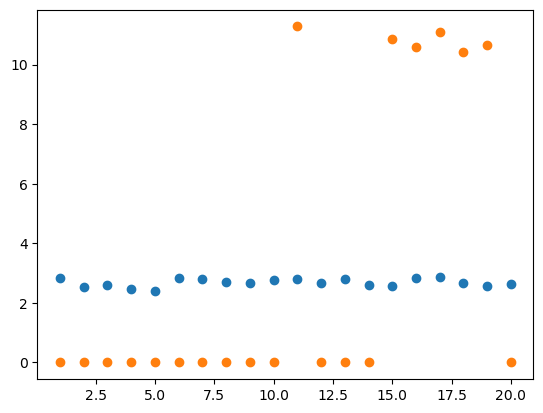

In [108]:

samplechainD = featuredf[featuredf['fileID'].str.contains("onweer_g_ch1", na=False)]
plt.plot(samplechainD['generation_number'], samplechainD['total_body_entropy2Daggregated'], marker='o', linestyle='')
plt.plot(samplechainD['generation_number'], samplechainD['total_body_entropy2D'], marker='o', linestyle='')



# Saves the df to the feature extraction file

In [109]:
globals()["feature_extraction"] = featuredf
globals()["feature_extraction"].to_csv(os.path.join(curfolder, f'{"feature_extraction_with2d_extended"}.csv'), index=False)

In [111]:
feature_extraction.columns


Index(['participantID', 'Age', 'BirthPlace', 'Gender', 'NativeLanguages',
       'NumOfNativeLanguages', 'Other Languages', 'TotalLanguages',
       'Extroversion', 'Hand', 'fileID', 'chainID', 'generation_number',
       'chain_number', 'gesture', 'gesture_chain', 'event',
       'ARM_TOTAL_speed2D_mean', 'ARM_TOTAL_speed2D_sd',
       'ARM_TOTAL_speed2D_range', 'LEG_TOTAL_speed2D_mean',
       'LEG_TOTAL_speed2D_sd', 'LEG_TOTAL_speed2D_range', 'left_index_space2D',
       'left_wrist_space2D', 'left_elbow_space2D', 'total_left_arm_space2D',
       'right_index_space2D', 'right_wrist_space2D', 'right_elbow_space2D',
       'total_right_arm_space2D', 'left_ankle_space2D', 'left_knee_space2D',
       'total_left_leg_space2D', 'right_ankle_space2D', 'right_knee_space2D',
       'total_right_leg_space2D', 'nose_space2D', 'total_head_space2D',
       'total_gesture_space2D', 'right_wrist_entropy2D',
       'left_wrist_entropy2D', 'right_knee_entropy2D', 'left_knee_entropy2D',
       'right

In [91]:
## testing the correlations
np.corrcoef(feature_extraction['right_wrist_space2D'], feature_extraction['left_wrist_entropy2D'])

array([[1.        , 0.64970068],
       [0.64970068, 1.        ]])